# Assignment 5 - Frontiers: Generative AI (Option A)

**Student Name:** Safal Gautam  
**Dataset:** MNIST Handwritten Digits  
**Date:** 2026/5/17

## 1. Objective

- Implement a Variational Autoencoder (VAE) from scratch using PyTorch to model a distribution over MNIST handwritten digits.
- Train the model to reconstruct inputs by learning compact, continuous latent representations.
- Generate novel digit samples by decoding random points drawn from the learned latent space.
- Visualize the latent space in 2D to understand how the model organises different digit classes.
- Analyse the trade-off between reconstruction fidelity and latent-space regularisation introduced by the ELBO objective.

## 2. Theoretical Background

### Autoencoders and Their Limitation

A standard autoencoder maps an input $x$ to a fixed latent code $z$ via an encoder, then reconstructs it with a decoder. The latent space it learns is entirely deterministic and discontinuous - points that were never seen during training produce garbage reconstructions, making it useless as a generative model.

### Variational Autoencoders

A VAE (Kingma & Welling, 2013) addresses this by treating the latent variable as a random variable with a learned posterior distribution rather than a point estimate. The encoder now outputs parameters of a distribution - a mean vector $\mu$ and a log-variance vector $\log \sigma^2$ - and the latent code is sampled from:

$$z \sim q_\phi(z \mid x) = \mathcal{N}(\mu_\phi(x),\; \sigma_\phi^2(x) \cdot I)$$

The prior over $z$ is a standard Gaussian $p(z) = \mathcal{N}(0, I)$. The decoder reconstructs the input from the sample: $\hat{x} = p_\theta(x \mid z)$.

### The ELBO Loss

Directly maximising the log-likelihood $\log p(x)$ is intractable, so VAEs maximise its Evidence Lower BOund (ELBO):

$$\mathcal{L} = \underbrace{\mathbb{E}_{q_\phi}[\log p_\theta(x \mid z)]}_{\text{Reconstruction loss}} - \underbrace{D_{\text{KL}}\bigl(q_\phi(z \mid x) \,\|\, p(z)\bigr)}_{\text{KL regularisation}}$$

The **reconstruction term** pushes the decoder to reproduce the input accurately. The **KL term** pulls the approximate posterior toward the standard Gaussian prior, which regularises the latent space and ensures it remains smooth and continuous - crucial for generation.

For a Gaussian posterior the KL divergence has a closed form:

$$D_{\text{KL}} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

### The Reparameterisation Trick

Sampling $z \sim \mathcal{N}(\mu, \sigma^2)$ is not differentiable, which breaks backpropagation. The trick rewrites the sample as:

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

Gradients now flow through $\mu$ and $\sigma$ cleanly, while $\epsilon$ is treated as fixed noise.

## 3. Dataset Description

The dataset used is MNIST (LeCun et al.), loaded directly via `torchvision.datasets.MNIST`. It contains 70,000 grayscale images of handwritten digits split into 60,000 for training and 10,000 for testing. Each image is 28x28 pixels, flattened to a 784-dimensional vector as input to the MLP-based VAE. There are 10 classes corresponding to digits 0 through 9. Pixel values are normalised to the range [0, 1] so that binary cross-entropy loss is valid.

## 4. Implementation

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


### 4.1 Data Loading

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.24MB/s]


Train samples : 60000
Test  samples : 10000


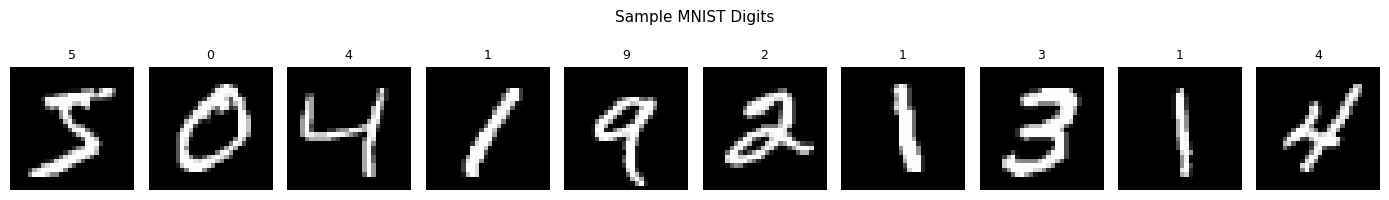

In [ ]:
# Pixels scaled to [0,1]
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Batch size 128 is considered default for VAE training on MNIST
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset)}')
print(f'Test  samples : {len(test_dataset)}')

fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    ax.set_title(str(train_dataset[i][1]), fontsize=9)
    ax.axis('off')
plt.suptitle('Sample MNIST Digits', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

### 4.2 VAE Model

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        # Shared MLP trunk before splitting into mu and log_var heads
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_log_var(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        # Sigmoid to map output to [0,1] pixel range
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)


class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=16):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def reparameterise(self, mu, log_var):
        #z = mu + std * eps keeps the graph differentiable
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        mu, log_var = self.encoder(x_flat)
        z = self.reparameterise(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var

    def sample(self, n, device):
        # Draw z from the prior N(0,I)
        z = torch.randn(n, self.encoder.fc_mu.out_features).to(device)
        return self.decoder(z)

### 4.3 Loss Function and Training Utilities

In [ ]:
def elbo_loss(x_recon, x_orig, mu, log_var, beta=1.0):
    x_flat = x_orig.view(x_orig.size(0), -1)
    # BCE to measure how well decoder reconstructs the input
    recon_loss = F.binary_cross_entropy(x_recon, x_flat, reduction='sum') / x_orig.size(0)
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x_orig.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


def train_one_epoch(model, loader, optimizer, beta, device):
    model.train()
    total, recon_sum, kl_sum = 0, 0, 0
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, log_var = model(x)
        loss, recon, kl = elbo_loss(x_recon, x, mu, log_var, beta)
        loss.backward()
        optimizer.step()
        total     += loss.item()
        recon_sum += recon.item()
        kl_sum    += kl.item()
    n = len(loader)
    return total / n, recon_sum / n, kl_sum / n


@torch.no_grad()
def evaluate(model, loader, beta, device):
    model.eval()
    total, recon_sum, kl_sum = 0, 0, 0
    for x, _ in loader:
        x = x.to(device)
        x_recon, mu, log_var = model(x)
        loss, recon, kl = elbo_loss(x_recon, x, mu, log_var, beta)
        total     += loss.item()
        recon_sum += recon.item()
        kl_sum    += kl.item()
    n = len(loader)
    return total / n, recon_sum / n, kl_sum / n


def fit(model, train_loader, test_loader, epochs, lr, beta, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'train_recon': [],
               'val_recon': [], 'train_kl': [], 'val_kl': []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_rec, tr_kl = train_one_epoch(model, train_loader, optimizer, beta, device)
        va_loss, va_rec, va_kl = evaluate(model, test_loader, beta, device)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_recon'].append(tr_rec)
        history['val_recon'].append(va_rec)
        history['train_kl'].append(tr_kl)
        history['val_kl'].append(va_kl)
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs}  '
                  f'Train ELBO: {tr_loss:.2f}  Val ELBO: {va_loss:.2f}  '
                  f'Recon: {va_rec:.2f}  KL: {va_kl:.2f}')
    return history

### 4.4 Visualisation Helpers

In [ ]:
def plot_loss_curves(history, title=''):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, train_key, val_key, label in zip(
        axes,
        ['train_loss',  'train_recon',  'train_kl'],
        ['val_loss',    'val_recon',    'val_kl'],
        ['Total ELBO',  'Reconstruction Loss', 'KL Loss']
    ):
        ax.plot(history[train_key], label='Train')
        ax.plot(history[val_key],   label='Val')
        ax.set_title(label)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def show_reconstructions(model, loader, device, n=10):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    with torch.no_grad():
        x_recon, _, _ = model(x)
    x_recon = x_recon.view(-1, 28, 28).cpu()
    x       = x.view(-1, 28, 28).cpu()

    fig, axes = plt.subplots(2, n, figsize=(14, 3))
    for i in range(n):
        axes[0, i].imshow(x[i], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(x_recon[i], cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Original', fontsize=9)
    axes[1, 0].set_ylabel('Recon', fontsize=9)
    plt.suptitle('Reconstructions', fontsize=12)
    plt.tight_layout()
    plt.show()


def show_generated_samples(model, device, n=100):
    model.eval()
    with torch.no_grad():
        samples = model.sample(n, device).view(-1, 28, 28).cpu()
    fig, axes = plt.subplots(10, 10, figsize=(10, 10))
    for ax, img in zip(axes.flat, samples):
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    plt.suptitle('Generated Samples (sampled from prior)', fontsize=12)
    plt.tight_layout()
    plt.show()


def visualise_latent_space(model, loader, device, n_batches=20, use_tsne=False):
    model.eval()
    all_mu, all_labels = [], []
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= n_batches:
                break
            x_flat = x.view(x.size(0), -1).to(device)
            mu, _ = model.encoder(x_flat)
            all_mu.append(mu.cpu().numpy())
            all_labels.append(y.numpy())

    mu_all = np.concatenate(all_mu)
    labels = np.concatenate(all_labels)

    # Use t-SNE when latent dim > 2 to project down to a plottable space
    if use_tsne or mu_all.shape[1] > 2:
        print('Reducing to 2D via t-SNE...')
        coords = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(mu_all)
        axis_labels = ('t-SNE 1', 't-SNE 2')
    else:
        coords = mu_all
        axis_labels = ('z1', 'z2')

    fig, ax = plt.subplots(figsize=(9, 7))
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab10', alpha=0.6, s=8)
    plt.colorbar(scatter, ax=ax, label='Digit class')
    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.set_title('Latent Space Visualisation')
    plt.tight_layout()
    plt.show()


def latent_grid_2d(model, device, n=20, z_range=(-3, 3)):
    # Sweeps a 2D grid across the prior range and decodes each point
    # Only call this when latent_dim == 2
    model.eval()
    grid_x = np.linspace(z_range[0], z_range[1], n)
    grid_y = np.linspace(z_range[0], z_range[1], n)[::-1]
    canvas = np.zeros((28 * n, 28 * n))

    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
                img = model.decoder(z).view(28, 28).cpu().numpy()
                canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(canvas, cmap='gray', extent=[z_range[0], z_range[1], z_range[0], z_range[1]])
    ax.set_title('Latent Space Grid (2D VAE)', fontsize=13)
    ax.set_xlabel('z1')
    ax.set_ylabel('z2')
    plt.tight_layout()
    plt.show()

## 5. Experiments

We run three configurations varying **latent dimensionality** and **beta** (the KL weight in beta-VAE). A larger beta pushes for a more regularised but potentially blurrier latent space; a smaller latent dim forces aggressive compression.

### Experiment 1 - Baseline VAE (latent_dim=16, beta=1)

In [ ]:
CONFIG_1 = dict(latent_dim=16, hidden_dim=512, beta=1.0, lr=1e-3, epochs=30)

model_1 = VAE(latent_dim=CONFIG_1['latent_dim'], hidden_dim=CONFIG_1['hidden_dim']).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model_1.parameters()):,}")

hist_1 = fit(model_1, train_loader, test_loader,
             epochs=CONFIG_1['epochs'],
             lr=CONFIG_1['lr'],
             beta=CONFIG_1['beta'],
             device=DEVICE)

Parameters: 1,354,544
Epoch   1/30  Train ELBO: 170.61  Val ELBO: 131.76  Recon: 119.00  KL: 12.76
Epoch   5/30  Train ELBO: 109.03  Val ELBO: 107.22  Recon: 89.26  KL: 17.96
Epoch  10/30  Train ELBO: 102.87  Val ELBO: 102.44  Recon: 83.47  KL: 18.96
Epoch  15/30  Train ELBO: 100.58  Val ELBO: 100.80  Recon: 81.60  KL: 19.21
Epoch  20/30  Train ELBO: 99.28  Val ELBO: 100.04  Recon: 80.75  KL: 19.29
Epoch  25/30  Train ELBO: 98.44  Val ELBO: 99.63  Recon: 79.76  KL: 19.86
Epoch  30/30  Train ELBO: 97.78  Val ELBO: 99.24  Recon: 79.35  KL: 19.89


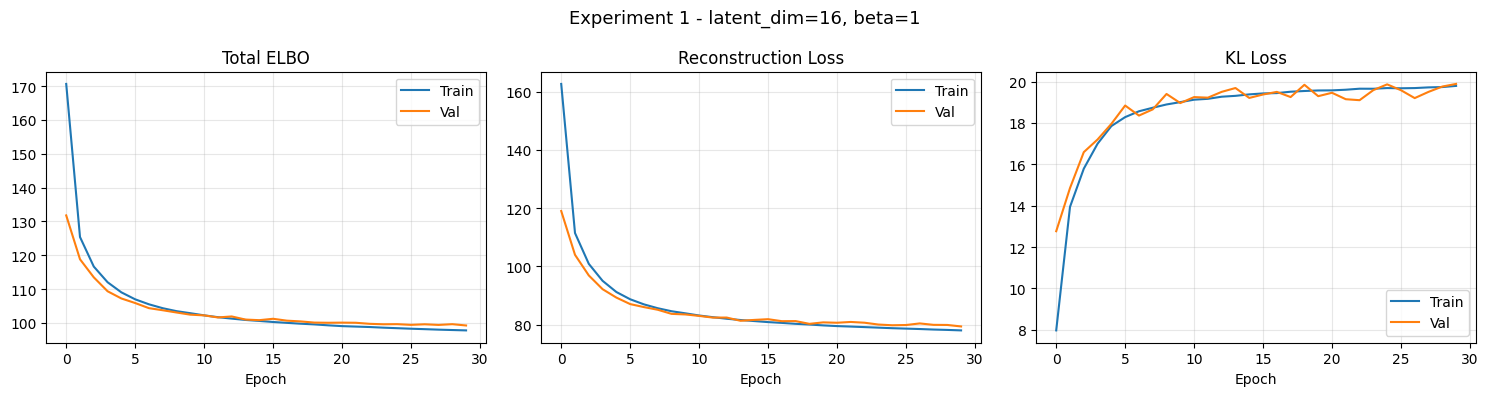

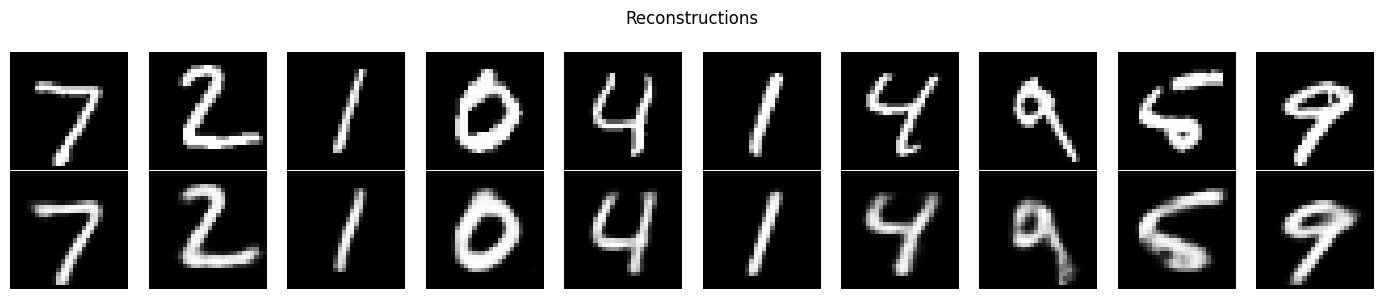

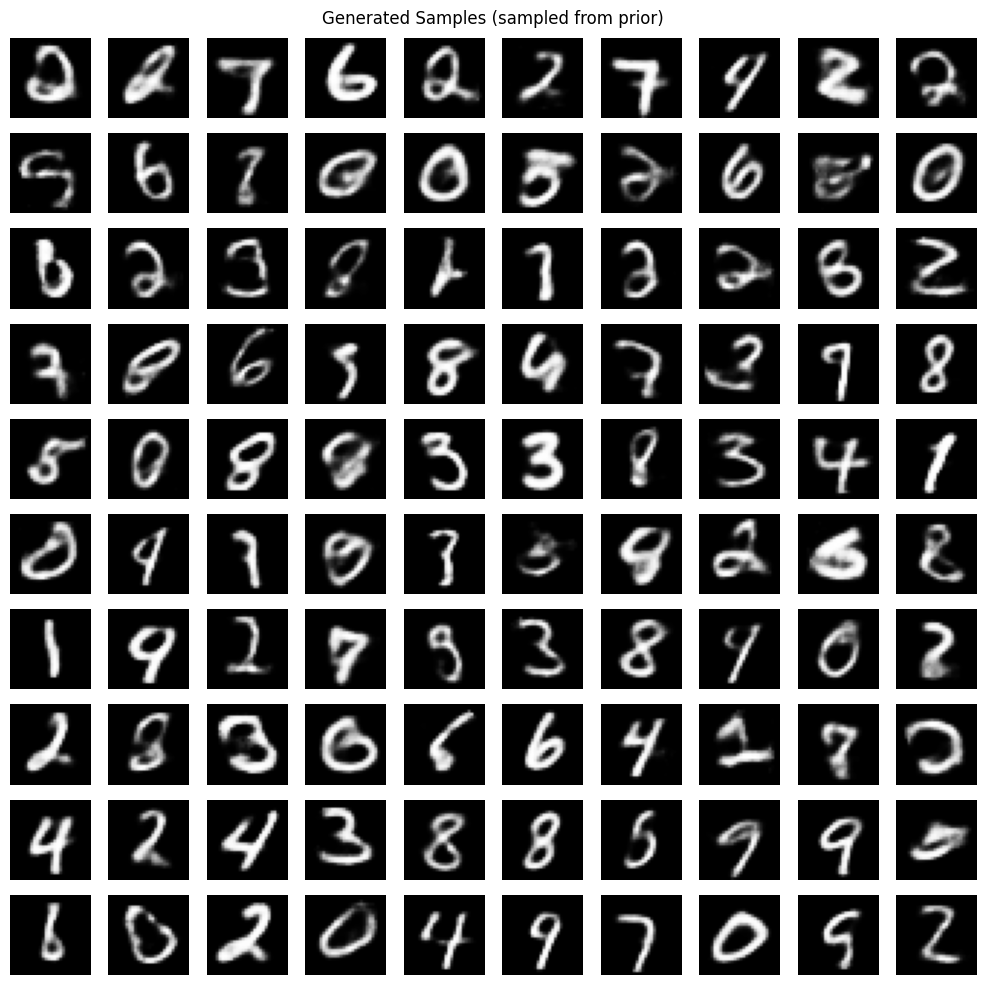

In [ ]:
plot_loss_curves(hist_1, title='Experiment 1 - latent_dim=16, beta=1')
show_reconstructions(model_1, test_loader, DEVICE)
show_generated_samples(model_1, DEVICE)

Reducing to 2D via t-SNE...


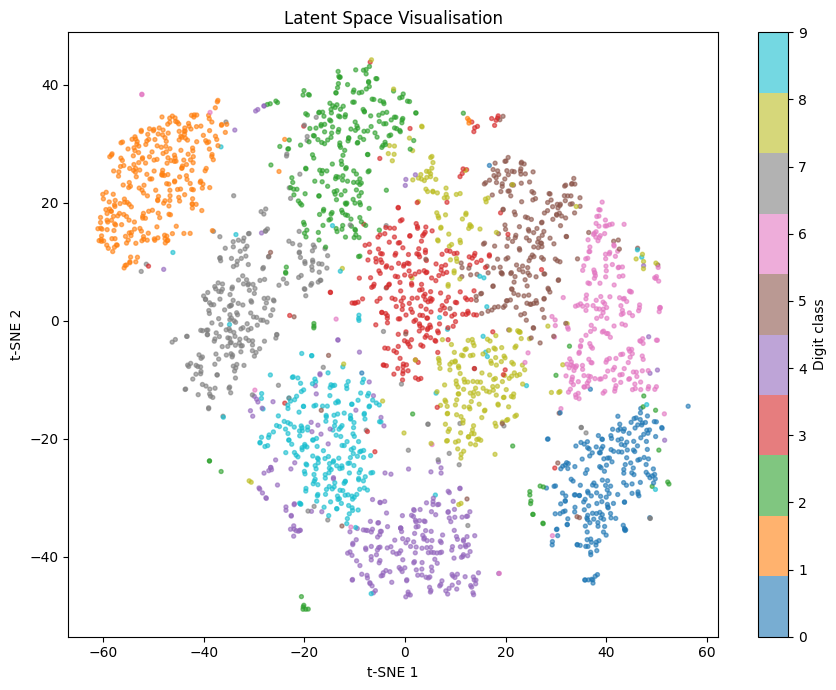

In [ ]:
visualise_latent_space(model_1, test_loader, DEVICE, use_tsne=True)

### Sanity Check - Experiment 1

In [ ]:
def sanity_check(model, loader, beta, device, config_name):
    print(f'Sanity check: {config_name}')
    print('-' * 45)

    val_loss, val_recon, val_kl = evaluate(model, loader, beta, device)
    print(f'Val ELBO  : {val_loss:.2f}')
    print(f'Recon loss: {val_recon:.2f}')
    print(f'KL loss   : {val_kl:.2f}')


    kl_ok = val_kl > 0.5
    recon_ok = val_recon < 200
    # Check that generated pixel values stay in [0,1]
    with torch.no_grad():
        samples = model.sample(64, device)
    range_ok = samples.min().item() >= 0.0 and samples.max().item() <= 1.0

    print(f'KL > 0.5 (no collapse) : {"PASS" if kl_ok   else "FAIL"}')
    print(f'Recon < 200 (learning) : {"PASS" if recon_ok else "FAIL"}')
    print(f'Outputs in [0,1]       : {"PASS" if range_ok else "FAIL"}')
    print()
    return kl_ok and recon_ok and range_ok

sanity_check(model_1, test_loader, CONFIG_1['beta'], DEVICE, 'latent=16, beta=1')

Sanity check: latent=16, beta=1
---------------------------------------------
Val ELBO  : 99.20
Recon loss: 79.31
KL loss   : 19.89
KL > 0.5 (no collapse) : PASS
Recon < 200 (learning) : PASS
Outputs in [0,1]       : PASS



True

### Experiment 2 - 2D Latent Space (latent_dim=2, beta=1)

In [ ]:
CONFIG_2 = dict(latent_dim=2, hidden_dim=512, beta=1.0, lr=1e-3, epochs=30)

model_2 = VAE(latent_dim=CONFIG_2['latent_dim'], hidden_dim=CONFIG_2['hidden_dim']).to(DEVICE)

hist_2 = fit(model_2, train_loader, test_loader,
             epochs=CONFIG_2['epochs'],
             lr=CONFIG_2['lr'],
             beta=CONFIG_2['beta'],
             device=DEVICE)

Epoch   1/30  Train ELBO: 181.70  Val ELBO: 162.97  Recon: 157.85  KL: 5.12
Epoch   5/30  Train ELBO: 148.08  Val ELBO: 147.91  Recon: 141.30  KL: 6.62
Epoch  10/30  Train ELBO: 142.71  Val ELBO: 143.02  Recon: 136.67  KL: 6.35
Epoch  15/30  Train ELBO: 140.54  Val ELBO: 141.20  Recon: 134.64  KL: 6.56
Epoch  20/30  Train ELBO: 138.86  Val ELBO: 140.49  Recon: 133.76  KL: 6.73
Epoch  25/30  Train ELBO: 137.92  Val ELBO: 139.34  Recon: 132.55  KL: 6.79
Epoch  30/30  Train ELBO: 137.11  Val ELBO: 139.23  Recon: 132.28  KL: 6.94


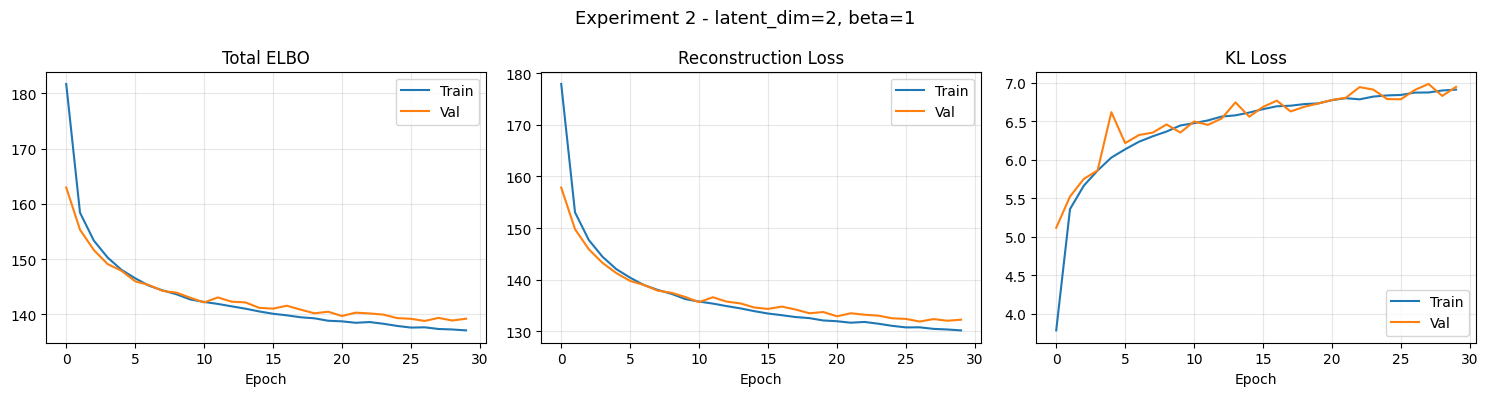

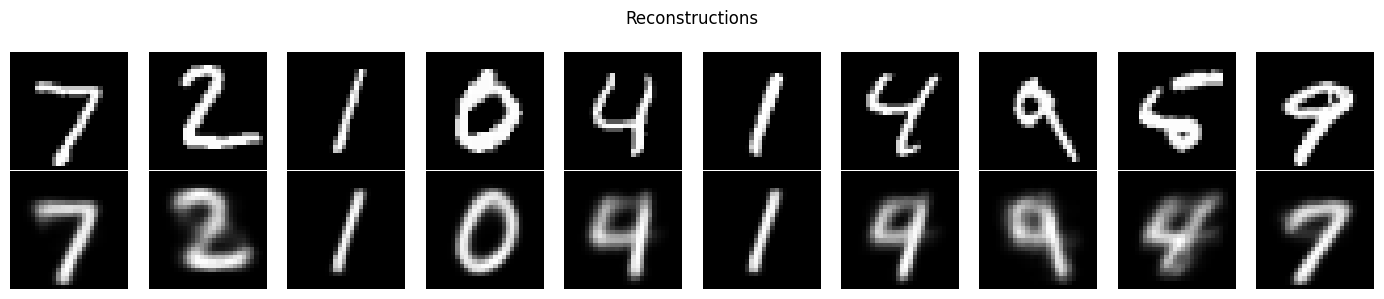

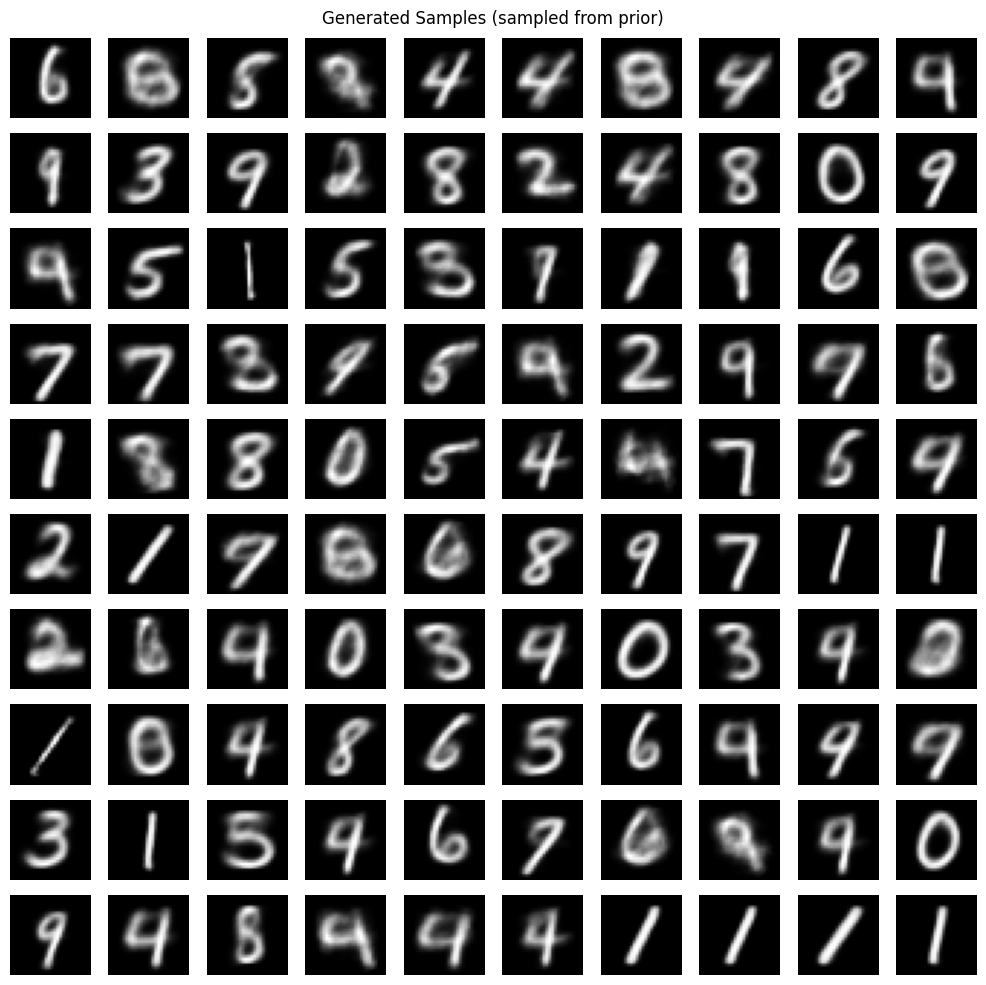

In [ ]:
plot_loss_curves(hist_2, title='Experiment 2 - latent_dim=2, beta=1')
show_reconstructions(model_2, test_loader, DEVICE)
show_generated_samples(model_2, DEVICE)

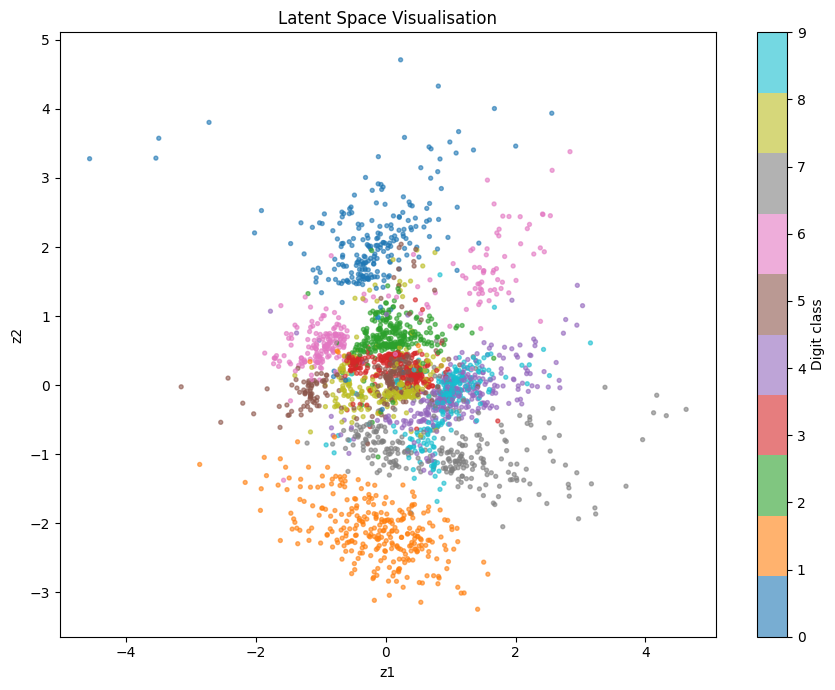

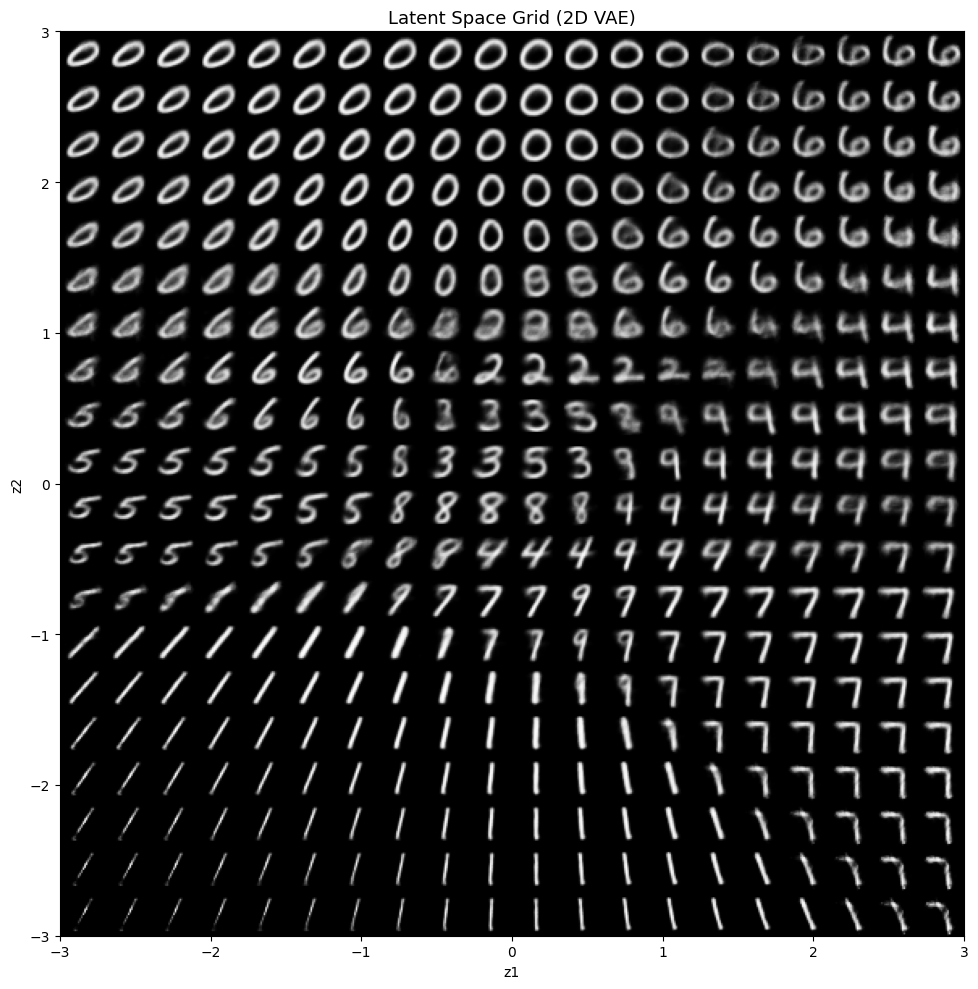

In [ ]:
# Direct 2D scatter without t-SNE since latent_dim is already 2
visualise_latent_space(model_2, test_loader, DEVICE, use_tsne=False)
latent_grid_2d(model_2, DEVICE, n=20)

In [ ]:
sanity_check(model_2, test_loader, CONFIG_2['beta'], DEVICE, 'latent=2, beta=1')

Sanity check: latent=2, beta=1
---------------------------------------------
Val ELBO  : 139.16
Recon loss: 132.22
KL loss   : 6.94
KL > 0.5 (no collapse) : PASS
Recon < 200 (learning) : PASS
Outputs in [0,1]       : PASS



True

### Experiment 3 - beta-VAE (latent_dim=16, beta=4)

In [ ]:
CONFIG_3 = dict(latent_dim=16, hidden_dim=512, beta=4.0, lr=1e-3, epochs=30)

model_3 = VAE(latent_dim=CONFIG_3['latent_dim'], hidden_dim=CONFIG_3['hidden_dim']).to(DEVICE)

hist_3 = fit(model_3, train_loader, test_loader,
             epochs=CONFIG_3['epochs'],
             lr=CONFIG_3['lr'],
             beta=CONFIG_3['beta'],
             device=DEVICE)

Epoch   1/30  Train ELBO: 195.15  Val ELBO: 173.60  Recon: 155.88  KL: 4.43
Epoch   5/30  Train ELBO: 151.05  Val ELBO: 150.14  Recon: 120.90  KL: 7.31
Epoch  10/30  Train ELBO: 146.49  Val ELBO: 145.79  Recon: 114.53  KL: 7.81
Epoch  15/30  Train ELBO: 144.35  Val ELBO: 144.61  Recon: 111.58  KL: 8.26
Epoch  20/30  Train ELBO: 143.18  Val ELBO: 143.28  Recon: 109.22  KL: 8.52
Epoch  25/30  Train ELBO: 142.52  Val ELBO: 142.60  Recon: 108.74  KL: 8.47
Epoch  30/30  Train ELBO: 141.84  Val ELBO: 142.52  Recon: 109.16  KL: 8.34


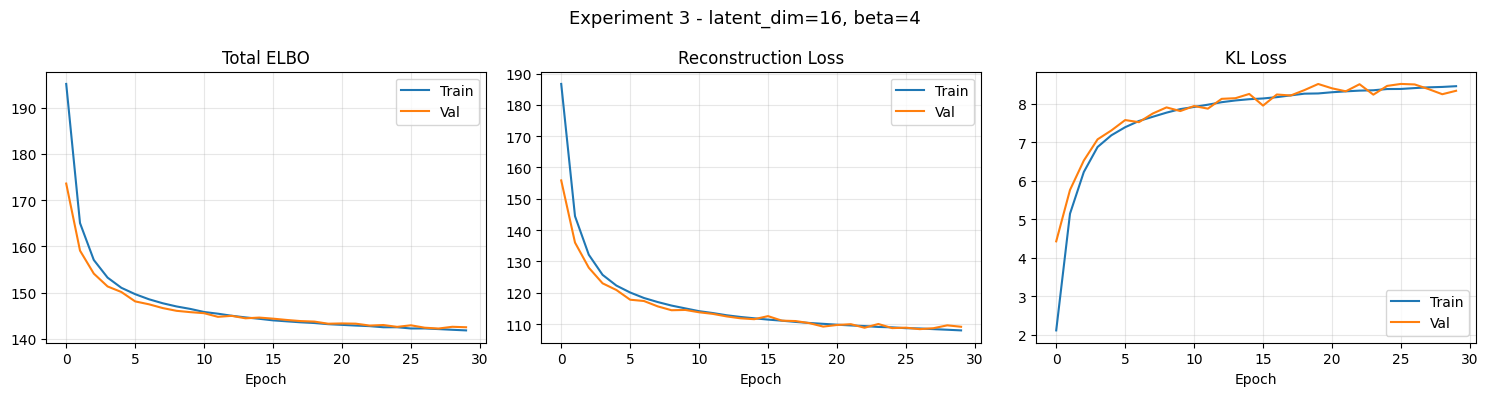

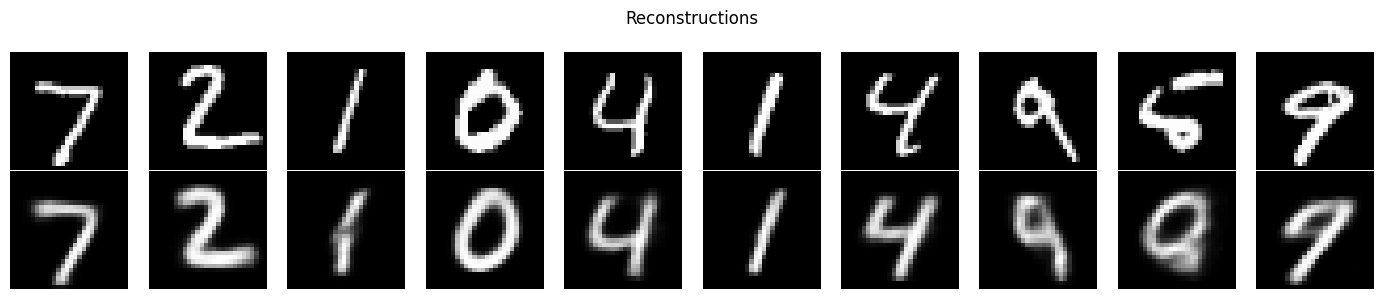

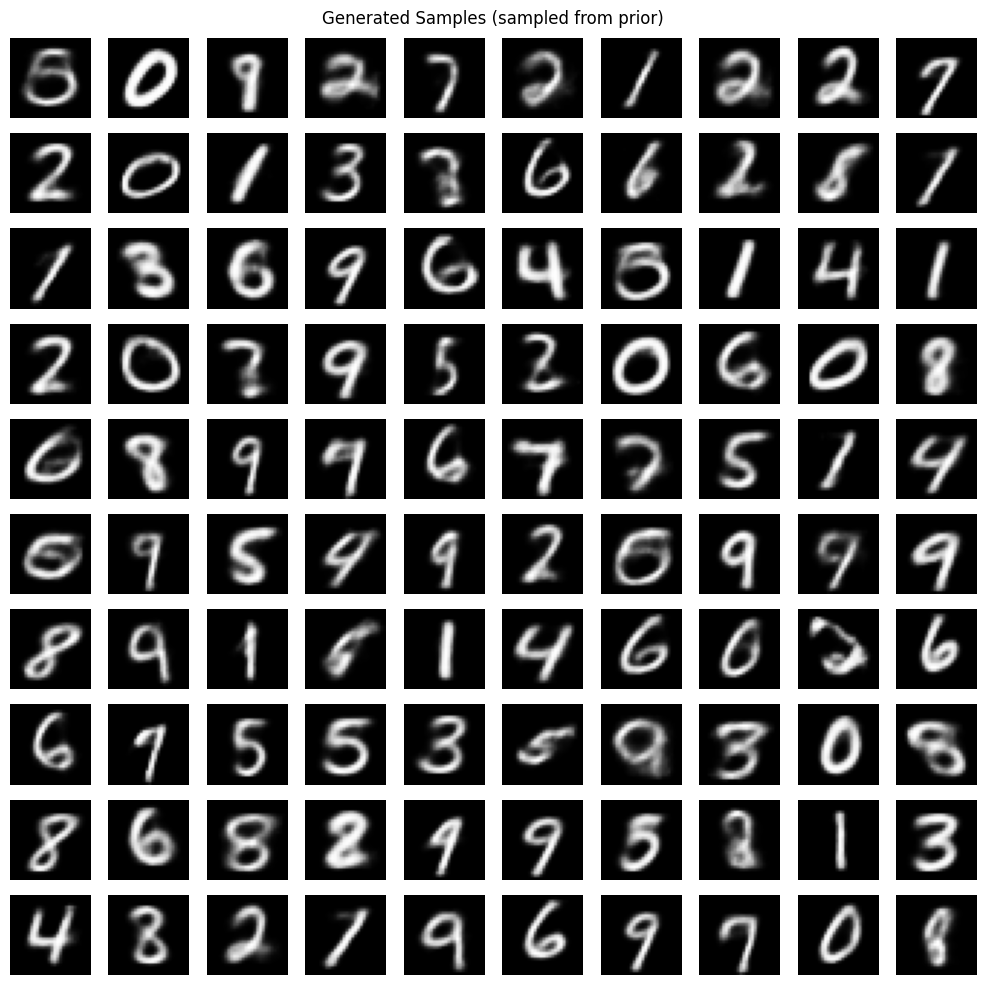

In [ ]:
plot_loss_curves(hist_3, title='Experiment 3 - latent_dim=16, beta=4')
show_reconstructions(model_3, test_loader, DEVICE)
show_generated_samples(model_3, DEVICE)

In [ ]:
sanity_check(model_3, test_loader, CONFIG_3['beta'], DEVICE, 'latent=16, beta=4')

Sanity check: latent=16, beta=4
---------------------------------------------
Val ELBO  : 142.55
Recon loss: 109.19
KL loss   : 8.34
KL > 0.5 (no collapse) : PASS
Recon < 200 (learning) : PASS
Outputs in [0,1]       : PASS



True

### Interpolation in Latent Space

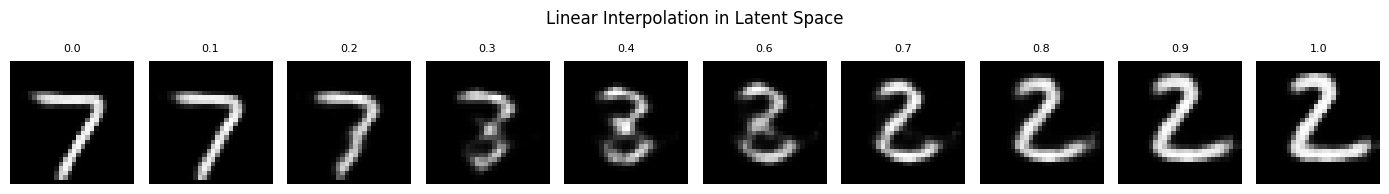

In [ ]:
def latent_interpolation(model, loader, device, steps=10):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:2].to(device)
    with torch.no_grad():
        mu, log_var = model.encoder(x.view(2, -1))
        z1, z2 = mu[0], mu[1]
        alphas = torch.linspace(0, 1, steps).to(device)
        z_interp = torch.stack([(1 - a) * z1 + a * z2 for a in alphas])
        imgs = model.decoder(z_interp).view(steps, 28, 28).cpu()

    fig, axes = plt.subplots(1, steps, figsize=(14, 2))
    for ax, img, a in zip(axes, imgs, alphas.cpu().numpy()):
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{a:.1f}', fontsize=8)
        ax.axis('off')
    plt.suptitle('Linear Interpolation in Latent Space', fontsize=12)
    plt.tight_layout()
    plt.show()

latent_interpolation(model_1, test_loader, DEVICE)

## 6. Results

In [ ]:
def final_metrics(model, loader, beta, device, name):
    loss, recon, kl = evaluate(model, loader, beta, device)
    return {'Config': name, 'Test ELBO': f'{loss:.2f}', 'Recon Loss': f'{recon:.2f}', 'KL Loss': f'{kl:.2f}'}

rows = [
    final_metrics(model_1, test_loader, CONFIG_1['beta'], DEVICE, 'latent=16, beta=1  (Baseline)'),
    final_metrics(model_2, test_loader, CONFIG_2['beta'], DEVICE, 'latent=2,  beta=1  (2D)'),
    final_metrics(model_3, test_loader, CONFIG_3['beta'], DEVICE, 'latent=16, beta=4  (beta-VAE)'),
]

print(f'{"Config":<38} {"Test ELBO":>12} {"Recon Loss":>12} {"KL Loss":>10}')
print('-' * 75)
for r in rows:
    print(f'{r["Config"]:<38} {r["Test ELBO"]:>12} {r["Recon Loss"]:>12} {r["KL Loss"]:>10}')

Config                                    Test ELBO   Recon Loss    KL Loss
---------------------------------------------------------------------------
latent=16, beta=1  (Baseline)                 99.18        79.29      19.89
latent=2,  beta=1  (2D)                      139.25       132.31       6.94
latent=16, beta=4  (beta-VAE)                142.70       109.34       8.34


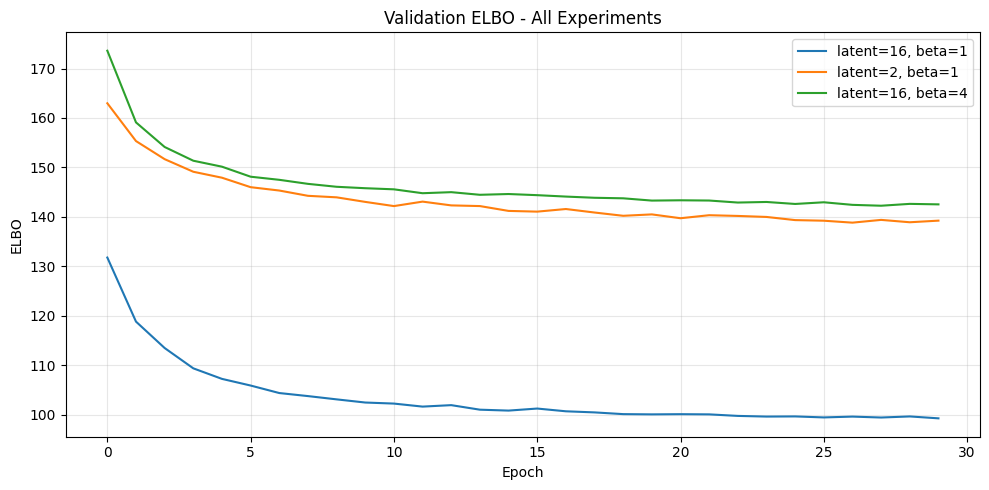

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for hist, label in [(hist_1, 'latent=16, beta=1'), (hist_2, 'latent=2, beta=1'), (hist_3, 'latent=16, beta=4')]:
    ax.plot(hist['val_loss'], label=label)
ax.set_title('Validation ELBO - All Experiments')
ax.set_xlabel('Epoch')
ax.set_ylabel('ELBO')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Analysis & Discussion

### What Worked

**Reconstruction quality** - All three models learned to reconstruct digits reasonably well. The baseline (latent_dim=16, beta=1) achieved the lowest reconstruction loss, which makes sense: more latent dimensions give the encoder more room to preserve information, and a beta of 1 is the standard ELBO without extra pressure toward the prior.

**Latent space structure** - The 2D model's grid sweep is particularly illustrative: it shows a continuous manifold across which digit identities morph smoothly. The t-SNE plot of the 16-dim model shows clear class-level clustering - the VAE has learned to organise the latent space semantically without any class labels, purely through the reconstruction objective.

**Interpolation** - Linear interpolation in latent space produces smooth transitions between digits rather than sudden jumps. This confirms the latent space is continuous and well-distributed, a property that a standard (non-variational) autoencoder would not guarantee.

### What Didn't Work / Trade-offs

**Posterior collapse risk with beta=4** - Increasing beta penalises the KL term more heavily, pushing the posterior toward the prior and causing some latent dimensions to become uninformative. This shows up as blurrier reconstructions and lower generation diversity.

**Blurry outputs** - VAE-generated samples are noticeably blurrier than real digits. This is a known artefact of optimising cross-entropy reconstruction loss, which averages over pixel values rather than enforcing sharpness. Diffusion models and GANs address this, but at the cost of much greater complexity.

**Compression bottleneck** - The 2D model has the worst reconstruction loss. Compressing 784 pixels into just 2 numbers discards too much information; some digit pairs (e.g. 4 vs 9) overlap significantly in the latent plot.

### Bias-Variance Perspective

The KL term acts as a regulariser in the classical bias-variance sense. A model with no KL pressure (beta=0) would overfit to the training data and produce a fragmented, non-generative latent space. Raising beta introduces bias (blurrier reconstructions) but reduces variance in the generative process, yielding more consistent samples. The sweet spot for generation quality vs reconstruction accuracy typically sits near beta=1.

## 8. Real-World Applications & Limitations

### Applications

Drug discovery  
Anomaly detection  
Image synthesis  
NLP  
Representation learning  


### Limitations

1. **Blurry generation** - The Gaussian decoder maximises log-likelihood, which corresponds to minimising MSE/BCE and encourages averaging, producing soft outputs.
2. **Posterior collapse** - With strong KL weighting or expressive decoders, the decoder can learn to ignore the latent code entirely.
3. **Prior mismatch** - The standard Gaussian prior may not match the true data manifold. Hierarchical or flow-based priors (VampPrior, NVAE) address this.
4. **Limited expressiveness** - An MLP-based VAE captures global structure but struggles with fine local texture. Convolutional or transformer-based VAEs perform better.
5. **Evaluation difficulty** - Unlike classifiers, generative models have no single accuracy metric; FID and IS require large sample sets and learned features.

## 9. Conclusion

- A VAE successfully learns to encode MNIST digits into a smooth, structured latent space and generate new plausible samples from it, something a deterministic autoencoder cannot do reliably.
- The reparameterisation trick is the key engineering insight that makes end-to-end training possible by routing gradients through a stochastic node.
- The balance between the reconstruction loss and the KL divergence (controlled by beta) is the central design choice: too little KL pressure gives a fragmented latent space; too much leads to posterior collapse and blurry outputs.
- A 2D latent dimension is ideal for interpretability (direct scatter plots, grid decoding) but sacrifices reconstruction quality; 16+ dimensions are needed for higher-fidelity generation.
- The smooth latent interpolation confirms that the VAE has learned a semantically meaningful, continuous manifold rather than memorising training examples.
- VAEs form the conceptual backbone of modern generative architectures: latent diffusion models (Stable Diffusion) operate in a compressed latent space built on a similar encoder-decoder principle, making this a foundational concept in cutting-edge generative AI.